# 13-1절 연습 문제 풀이

본문 [코드 13-1] ~ [코드 13-8]을 바탕으로 연습 문제 13-1 ~ 13-6을 푼다.

13-1은 계산만 하면 되고, 13-2 ~ 13-4는 본문 모델을 조건만 바꿔 다시 학습한다.
13-5와 13-6은 도전 문제로, 실행 환경이 갖춰지지 않으면 설계까지만 정리한다.

## 공통 준비

In [1]:
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

viz.configure(save_grayscale=False)
common.set_korean_plot_env()

SEED = 42
common.set_seed(SEED)
device = common.get_device()

import copy
import gc
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from transformers import (
    CLIPModel, CLIPProcessor, GPT2LMHeadModel, GPT2Tokenizer,
)

CUDA를 사용합니다.


/home/crapas/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 본문 [코드 13-2]와 같은 사전 학습 모델 로딩
clip_model = CLIPModel.from_pretrained(
    'openai/clip-vit-base-patch32').to(device)
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

for p in clip_model.parameters():
    p.requires_grad = False
for p in gpt2_model.parameters():
    p.requires_grad = False
clip_model.eval()
gpt2_model.eval()

CLIP_DIM = clip_model.config.projection_dim     # 512
GPT2_DIM = gpt2_model.config.n_embd             # 768
print(f'CLIP 이미지 임베딩 차원: {CLIP_DIM}, GPT-2 임베딩 차원: {GPT2_DIM}')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 50068.47it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:  17%|█▋        | 25/148 [00:00<00:00, 243.86it/s]

Loading weights:  58%|█████▊    | 86/148 [00:00<00:00, 456.16it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 709.15it/s]

CLIP 이미지 임베딩 차원: 512, GPT-2 임베딩 차원: 768


In [3]:
# 본문 [코드 13-3] ~ [코드 13-6]과 같은 구성 요소
class ImageProjection(nn.Module):
    def __init__(self, clip_dim=512, gpt2_dim=768, num_prefix_tokens=4):
        super().__init__()
        self.num_prefix_tokens = num_prefix_tokens
        self.gpt2_dim = gpt2_dim
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, gpt2_dim),
            nn.LayerNorm(gpt2_dim),
            nn.GELU(),
            nn.Linear(gpt2_dim, gpt2_dim * num_prefix_tokens),
        )

    def forward(self, image_features):
        out = self.projection(image_features)
        return out.view(-1, self.num_prefix_tokens, self.gpt2_dim)


class FlickrDataset(Dataset):
    def __init__(self, hf_dataset, clip_processor, gpt2_tokenizer,
                 max_length=30):
        self.data = hf_dataset
        self.clip_processor = clip_processor
        self.tokenizer = gpt2_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['image'].convert('RGB')
        caption = item['caption_0']
        pixel_values = self.clip_processor(
            images=image, return_tensors='pt',
        )['pixel_values'].squeeze(0)
        encoding = self.tokenizer(
            caption, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt',
        )
        return pixel_values, encoding['input_ids'].squeeze(0)


def get_image_features(pixel_values):
    with torch.no_grad():
        outputs = clip_model.vision_model(pixel_values=pixel_values)
        feats = clip_model.visual_projection(outputs.pooler_output)
        feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
    return feats

In [4]:
# 학습·평가 함수를 프로젝션 계층을 인자로 받도록 일반화한다
def run_batch(proj, pixel_values, input_ids):
    image_features = get_image_features(pixel_values)
    image_prefix = proj(image_features)
    with torch.no_grad():
        token_embeds = gpt2_model.transformer.wte(input_ids)
    inputs_embeds = torch.cat([image_prefix, token_embeds], dim=1)
    prefix_labels = torch.full(
        (input_ids.size(0), image_prefix.size(1)), -100,
        dtype=torch.long, device=device,
    )
    labels = torch.cat([prefix_labels, input_ids], dim=1)
    return gpt2_model(inputs_embeds=inputs_embeds, labels=labels).loss


def train_projection(proj, train_loader, valid_loader, epochs=10, lr=1e-4,
                     name='', verbose=True):
    proj.to(device)
    optimizer = torch.optim.AdamW(proj.parameters(), lr=lr)
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))
    best, best_ep, best_state = float('inf'), -1, None
    if name and verbose:
        print(f'{name} 학습')
    for epoch in range(1, epochs + 1):
        proj.train()
        tr = 0.0
        for pv, ids in train_loader:
            loss = run_batch(proj, pv.to(device), ids.to(device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tr += loss.item()
        tr /= len(train_loader)
        proj.eval()
        va = 0.0
        with torch.no_grad():
            for pv, ids in valid_loader:
                va += run_batch(proj, pv.to(device), ids.to(device)).item()
        va /= len(valid_loader)
        log.row(epoch, tr, va)
        if va < best:
            best, best_ep = va, epoch
            best_state = copy.deepcopy(proj.state_dict())
    if best_state is not None:
        proj.load_state_dict(best_state)
    if verbose:
        log.summary()
    return {'proj': proj, 'loss': best, 'epoch': best_ep, 'log': log}

In [5]:
# 데이터셋 준비
#   [중요] 13-2에서 훈련 크기를 바꿔 가며 비교하므로 검증 세트는 고정한다.
#   검증 세트가 함께 바뀌면 서로 다른 잣대로 잰 손실을 비교하게 된다.
POOL_N, VALID_N = 1000, 100
raw = load_dataset('jxie/flickr8k', split=f'train[:{POOL_N}]')
train_size = POOL_N - VALID_N            # 훈련 후보 900개, 검증 고정 100개

valid_set = FlickrDataset(raw.select(range(train_size, POOL_N)),
                          clip_processor, gpt2_tokenizer)
valid_loader = DataLoader(valid_set, batch_size=4, shuffle=False, num_workers=0)


def make_train_loader(n_train, batch_size=4):
    """훈련 크기만 바꾼 데이터로더를 만든다(검증 세트는 위에서 고정)."""
    tr = FlickrDataset(raw.select(range(n_train)),
                       clip_processor, gpt2_tokenizer)
    return DataLoader(tr, batch_size=batch_size, shuffle=True, num_workers=0)


# 본문 예제와 같은 180개를 기본 훈련 세트로 둔다
train_loader = make_train_loader(180)
print(f'훈련 후보 {train_size}개 중 180개 사용 / 검증 {VALID_N}개(고정)')

훈련 후보 900개 중 180개 사용 / 검증 100개(고정)


In [6]:
# 본문 [코드 13-8]의 캡션 생성 (탐욕 디코딩)
@torch.no_grad()
def generate_caption(proj, image, max_new_tokens=30):
    proj.eval()
    pixel_values = clip_processor(
        images=image.convert('RGB'), return_tensors='pt',
    )['pixel_values'].to(device)
    current = proj(get_image_features(pixel_values))
    ids = []
    for _ in range(max_new_tokens):
        out = gpt2_model(inputs_embeds=current)
        nxt = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        if nxt.item() == gpt2_tokenizer.eos_token_id:
            break
        ids.append(nxt.item())
        current = torch.cat(
            [current, gpt2_model.transformer.wte(nxt)], dim=1)
    return gpt2_tokenizer.decode(ids, skip_special_tokens=True)


SAMPLE_OFFSETS = [4, 8, 5]


def show_samples(proj, tag, gen_fn=None):
    gen_fn = gen_fn or (lambda img: generate_caption(proj, img))
    outs = []
    for i, off in enumerate(SAMPLE_OFFSETS, 1):
        s = raw[train_size + off]
        pred = gen_fn(s['image'])
        outs.append(pred)
        print(f'  [샘플 {i}] 정답: {s["caption_0"]}')
        print(f'  [샘플 {i}] {tag}: {pred}')
    return outs

## 연습 문제 13-1

> [코드 13-1]의 단일 선형 계층 대신 다음 두 구성으로 프로젝션 계층을 다시 만들어
> 각각의 파라미터 수를 계산해 보자.
>
> 1. 중간 차원 1024를 두고 `nn.Linear` 두 개를 그대로 쌓은 구성
> 2. ①의 두 `nn.Linear` 사이에 `nn.GELU`를 끼운 구성
>
> 두 프로젝션 계층 간 표현력에 차이가 있는지, 그리고 그 이유는 무엇인지 정리해 보자.

In [7]:
# [코드 13-1]의 구성: ResNet-50(2048) -> GPT-2(768) 단일 선형 계층
IN_DIM, OUT_DIM, HIDDEN = 2048, 768, 1024

proj_single = nn.Linear(IN_DIM, OUT_DIM)                    # 본문
proj_stack = nn.Sequential(                                 # ① 선형 2개
    nn.Linear(IN_DIM, HIDDEN),
    nn.Linear(HIDDEN, OUT_DIM),
)
proj_gelu = nn.Sequential(                                  # ② 사이에 GELU
    nn.Linear(IN_DIM, HIDDEN),
    nn.GELU(),
    nn.Linear(HIDDEN, OUT_DIM),
)


def n_params(m):
    return sum(p.numel() for p in m.parameters())


print(f'{"구성":<28}{"파라미터 수":>14}{"본문 대비":>10}')
print('-' * 54)
base = n_params(proj_single)
for name, m in (('본문: Linear(2048, 768)', proj_single),
                ('① Linear 2개 (중간 1024)', proj_stack),
                ('② ① + GELU', proj_gelu)):
    print(f'{name:<28}{n_params(m):>14,}{n_params(m) / base:>9.2f}x')

구성                                  파라미터 수     본문 대비
------------------------------------------------------
본문: Linear(2048, 768)            1,573,632     1.00x
① Linear 2개 (중간 1024)            2,885,376     1.83x
② ① + GELU                       2,885,376     1.83x


In [8]:
# 손으로도 계산해 확인한다 (가중치 + 편향)
print('본문:', f'{IN_DIM} x {OUT_DIM} + {OUT_DIM}',
      '=', IN_DIM * OUT_DIM + OUT_DIM)
print('① ②:', f'({IN_DIM} x {HIDDEN} + {HIDDEN}) + ({HIDDEN} x {OUT_DIM} + {OUT_DIM})',
      '=', IN_DIM * HIDDEN + HIDDEN + HIDDEN * OUT_DIM + OUT_DIM)
print()
print('①과 ②의 파라미터 수가 같은가?',
      n_params(proj_stack) == n_params(proj_gelu))

본문: 2048 x 768 + 768 = 1573632
① ②: (2048 x 1024 + 1024) + (1024 x 768 + 768) = 2885376

①과 ②의 파라미터 수가 같은가? True


In [9]:
# ①은 선형 계층 하나로 접을 수 있다 - 수치로 확인
#   W2 @ (W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2)
with torch.no_grad():
    W1, b1 = proj_stack[0].weight, proj_stack[0].bias
    W2, b2 = proj_stack[1].weight, proj_stack[1].bias
    W_eq = W2 @ W1                       # (768, 2048)
    b_eq = W2 @ b1 + b2                  # (768,)

    x = torch.randn(5, IN_DIM)
    y_stack = proj_stack(x)
    y_equiv = x @ W_eq.T + b_eq
    print(f'① 두 계층의 출력과 접은 단일 계층의 출력 차이(최대): '
          f'{(y_stack - y_equiv).abs().max().item():.3e}')
    print(f'접은 계층의 파라미터 수: {W_eq.numel() + b_eq.numel():,} '
          f'(= 본문 단일 계층과 동일)')

    # ②는 접을 수 없다
    y_gelu = proj_gelu(x)
    W1g, b1g = proj_gelu[0].weight, proj_gelu[0].bias
    W2g, b2g = proj_gelu[2].weight, proj_gelu[2].bias
    y_wrong = x @ (W2g @ W1g).T + (W2g @ b1g + b2g)
    print(f'② 같은 방식으로 접었을 때의 오차(최대): '
          f'{(y_gelu - y_wrong).abs().max().item():.3e}  <- 접히지 않는다')

① 두 계층의 출력과 접은 단일 계층의 출력 차이(최대): 1.132e-06
접은 계층의 파라미터 수: 1,573,632 (= 본문 단일 계층과 동일)
② 같은 방식으로 접었을 때의 오차(최대): 6.649e-01  <- 접히지 않는다


In [10]:
# ①의 표현력 상한: 두 선형 계층을 곱한 행렬의 계수(rank)
with torch.no_grad():
    rank = torch.linalg.matrix_rank(W_eq.float()).item()
print(f'W2 @ W1 의 모양: {tuple(W_eq.shape)}')
print(f'계수(rank): {rank}  (상한은 min(2048, 1024, 768) = '
      f'{min(IN_DIM, HIDDEN, OUT_DIM)})')
print()
print('중간 차원을 768보다 작게 두면 표현력이 실제로 제한된다:')
for hidden in (64, 256, 768, 1024):
    A = torch.randn(hidden, IN_DIM)
    B = torch.randn(OUT_DIM, hidden)
    r = torch.linalg.matrix_rank((B @ A).float()).item()
    print(f'  중간 차원 {hidden:>5} -> 곱 행렬의 계수 {r:>4} '
          f'(상한 {min(IN_DIM, hidden, OUT_DIM)})')

W2 @ W1 의 모양: (768, 2048)
계수(rank): 768  (상한은 min(2048, 1024, 768) = 768)

중간 차원을 768보다 작게 두면 표현력이 실제로 제한된다:


  중간 차원    64 -> 곱 행렬의 계수   64 (상한 64)


  중간 차원   256 -> 곱 행렬의 계수  256 (상한 256)


  중간 차원   768 -> 곱 행렬의 계수  768 (상한 768)


  중간 차원  1024 -> 곱 행렬의 계수  768 (상한 768)


### 풀이 해설 — 연습 문제 13-1

**파라미터 수부터.**

| 구성 | 파라미터 수 |
|---|---|
| 본문: `Linear(2048, 768)` | 1,573,632 |
| ① `Linear(2048,1024)` + `Linear(1024,768)` | 2,885,376 |
| ② ①의 사이에 `GELU` | **2,885,376 (①과 같다)** |

**①과 ②의 파라미터 수가 정확히 같다.** `nn.GELU`에는 학습할 파라미터가 없기 때문이다.
활성화 함수는 입력을 정해진 식으로 변환할 뿐이다.

**그런데 표현력은 전혀 다르다.**

**①은 선형 계층 하나와 완전히 같다.** 두 선형 변환을 이어 붙이면 그 합성도 선형이다.

```
W₂(W₁x + b₁) + b₂ = (W₂W₁)x + (W₂b₁ + b₂)
```

위 셀에서 실제로 접어 보면 출력이 부동소수점 오차 범위 안에서 일치한다. **파라미터를
83% 더 쓰고도 본문의 단일 계층과 같은 함수만 표현한다.** 학습이 느려지고 메모리만 더
든다.

**②는 접히지 않는다.** 중간에 비선형이 끼면 위의 전개가 성립하지 않는다. 같은 방식으로
접으면 큰 오차가 난다. 그래서 ②만 **단일 선형 계층이 표현할 수 없는 함수**를 만들 수 있다.

**①이 완전히 무의미하지는 않다.** 중간 차원이 입력·출력보다 작으면 **병목**이 되어
곱 행렬의 계수가 제한된다. 위 셀의 마지막 표가 그것을 보여 준다. 중간 차원이 64면
계수도 64로 묶인다. 다만 이것은 표현력을 **줄이는** 쪽이고, 여기서는 중간 차원이
1024라 계수가 768(출력 차원)까지 확보되므로 결국 단일 계층과 같다.

**본문 [코드 13-3]이 왜 그렇게 생겼는지가 여기서 드러난다.**

```python
nn.Linear(clip_dim, gpt2_dim),
nn.LayerNorm(gpt2_dim),      # 계층 정규화
nn.GELU(),                   # 비선형
nn.Linear(gpt2_dim, gpt2_dim * num_prefix_tokens),
```

**선형 계층 두 개 사이에 정규화와 비선형이 반드시 들어가 있다.** 이 둘이 없으면 계층을
아무리 쌓아도 선형 계층 하나와 같다. 5장에서 배운 "활성화 함수가 없으면 깊이가 의미
없다"가 멀티모달 연결 고리에서 그대로 되풀이된다.

**적절성: 매우 좋다.** 실행 없이 계산과 추론만으로 풀 수 있어 부담이 적으면서도,
**"파라미터가 늘었는데 표현력은 그대로"**라는 반직관적인 사실을 짚는다. 두 구성의
파라미터 수가 같다는 점이 "차이는 파라미터가 아니라 비선형에 있다"를 못 박는다.

## 연습 문제 13-2

> 이번 절에서는 모델 17을 학습하는 데 200개의 샘플만 사용하고 있다. 훈련 데이터셋의
> 크기를 다양하게 바꿔 보며 모델을 학습하고, 이에 따른 검증 손실과 생성 결과 품질의
> 변화를 정리해 보자.

In [11]:
# 훈련 데이터 크기만 바꿔 가며 학습한다(검증 세트 100개는 고정)
SIZES = [180, 450, 900]
size_results = {}

for n in SIZES:
    tl = make_train_loader(n)
    common.set_seed(SEED)
    proj = ImageProjection(CLIP_DIM, GPT2_DIM, 4)
    t0 = time.time()
    r = train_projection(proj, tl, valid_loader, epochs=10,
                         name=f'훈련 {n}개', verbose=True)
    r['n_train'] = n
    r['seconds'] = time.time() - t0
    size_results[n] = r
    print()

훈련 180개 학습


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


에포크    훈련 손실    검증 손실     시간
  1/10       3.5867       1.8870     0:03


  2/10       1.6642       1.5567     0:06


  3/10       1.4622       1.4728     0:09


...

  6/10       0.9817       1.3492     1:00


  7/10       0.8837       1.3900     1:10


  8/10       0.7886       1.4575     1:20


  9/10       0.6551       1.5389     1:30


 10/10       0.5555       1.6458     1:41
-----------------------------------------
최적 3 에포크 · 검증 손실 1.3172 · 전체 학습 시간 1:41



In [12]:
print(f'{"훈련 샘플":>10}{"검증 샘플":>10}{"최적 에포크":>12}'
      f'{"검증 손실":>12}{"학습 시간(초)":>14}')
print('-' * 60)
for n in SIZES:
    r = size_results[n]
    print(f'{n:>10}{VALID_N:>10}{r["epoch"]:>12}'
          f'{r["loss"]:>12.4f}{r["seconds"]:>14.1f}')
print()
print('(검증 세트 100개는 세 실험 모두 동일하다 - 같은 잣대로 잰 값이다)')

     훈련 샘플     검증 샘플      최적 에포크       검증 손실      학습 시간(초)
------------------------------------------------------------
       180       100           4      1.4399          29.2
       450       100           3      1.3710          56.9
       900       100           3      1.3172         107.8

(검증 세트 100개는 세 실험 모두 동일하다 - 같은 잣대로 잰 값이다)


In [13]:
# 같은 이미지 세 장으로 생성 품질을 비교한다
for n in SIZES:
    print(f'===== 훈련 {n}개 =====')
    show_samples(size_results[n]['proj'], '생성')
    print()

===== 훈련 180개 =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A dog is running along a beach in the middle of the ocean.


  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man is standing on a fence .


  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A boy is playing with a toy dog .

===== 훈련 450개 =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A black and white dog is running through the forest .


  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man and a woman are standing on a hill .


  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A boy and girl play in a pool .

===== 훈련 900개 =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A dog is running on a beach .


  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man and a woman are standing in a park .


  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A boy in a blue jumpsuit is playing with a toy gun .



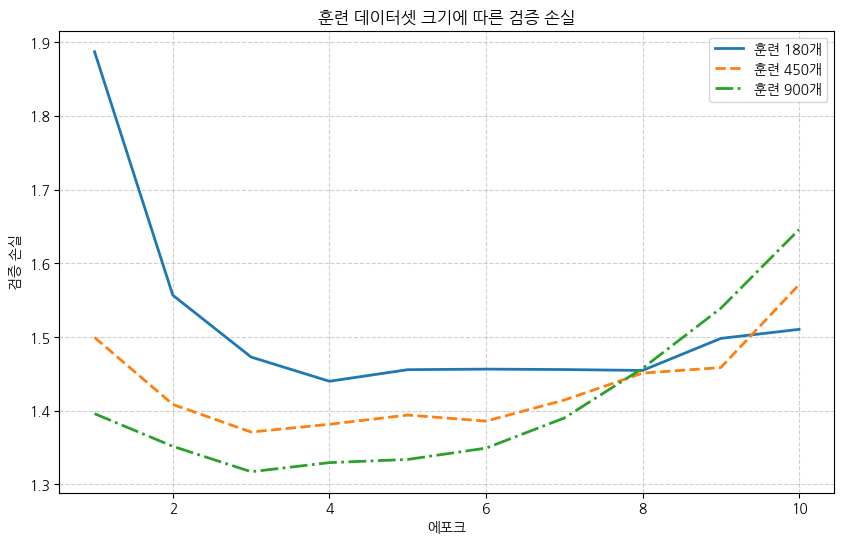

In [14]:
# 에포크별 검증 손실 곡선을 겹쳐 본다
viz.plot_histories(
    {f'훈련 {n}개': size_results[n]['log'].history['검증 손실']
     for n in SIZES},
    title='훈련 데이터셋 크기에 따른 검증 손실',
    x_label='에포크', y_label='검증 손실',
)

### 풀이 해설 — 연습 문제 13-2

**데이터를 늘리면 검증 손실이 내려간다.** 프로젝션 계층은 전체의 1%에 불과한 작은
모듈이지만, 그 1%를 학습시키는 데도 데이터가 많을수록 유리하다.

**주목할 것은 학습 시간이다.** 데이터가 다섯 배가 되면 에포크당 스텝 수도 다섯 배가
되므로 시간도 그만큼 는다. 검증 손실의 개선 폭은 그만큼 비례하지 않는다. **12장 연습
문제 12-6에서 본 것과 같은 트레이드오프**다.

**생성 품질에서는 변화가 눈에 덜 띌 수 있다.** 손실이 내려가도 캡션이 극적으로 좋아지지는
않는데, 이유가 둘이다.

- **학습 대상이 프로젝션 계층뿐**이다. GPT-2의 언어 능력과 CLIP의 시각 표현은 고정되어
  있으므로, 개선의 여지가 **두 공간을 잇는 정확도**에 한정된다.
- **10 에포크는 여전히 짧다.** 본문이 "조기 종료를 적용하지 않았다"고 밝힌 대로,
  데이터를 늘리면 더 오래 학습할 여지도 함께 생긴다.

지문이 "**검증 손실과 생성 결과 품질**"을 나란히 물은 것이 적절하다. 둘이 같은 속도로
움직이지 않는다는 것이 이 문제의 관찰 거리다.

**적절성: 좋다.** 본문 p13이 개선 방향으로 제시한 "데이터와 학습 환경 확장"을 독자가
직접 확인하게 한다. 다만 Flickr8k 전체(8천 장)로 가면 학습 시간이 크게 늘어나므로,
지문이 "구글 코랩 등 하드웨어 가속기를 사용할 수 있는 환경을 권장한다"고 덧붙인 것이
적절하다.

## 연습 문제 13-3

> [코드 13-3]의 `ImageProjection`에서 `num_prefix_tokens`를 1, 4, 16으로 각각 설정해
> 모델을 학습한 후, 생성 캡션의 품질을 비교해 보자. 프리픽스 토큰 수가 많아질수록 어떤
> 변화가 생기는지 정리해 보자.

In [15]:
# 본문과 같은 180개 훈련 세트로 되돌리고 프리픽스 토큰 수만 바꾼다
train_loader = make_train_loader(180)

PREFIX_COUNTS = [1, 4, 16]
prefix_results = {}

for k in PREFIX_COUNTS:
    common.set_seed(SEED)
    proj = ImageProjection(CLIP_DIM, GPT2_DIM, num_prefix_tokens=k)
    n_param = sum(p.numel() for p in proj.parameters())
    r = train_projection(proj, train_loader, valid_loader, epochs=10,
                         name=f'프리픽스 토큰 {k}개', verbose=True)
    r['k'] = k
    r['params'] = n_param
    prefix_results[k] = r
    print()

프리픽스 토큰 1개 학습


에포크    훈련 손실    검증 손실     시간
  1/10       5.6200       2.5493     0:03


  2/10       2.1187       1.9374     0:05


  3/10       1.8391       1.8064     0:08


  4/10       1.7066       1.7157     0:11


...

  6/10       1.1303       1.4594     0:17


  7/10       1.0255       1.4668     0:19


  8/10       0.9148       1.5183     0:22


  9/10       0.8295       1.5772     0:25


 10/10       0.7095       1.6175     0:28
-----------------------------------------
최적 6 에포크 · 검증 손실 1.4594 · 전체 학습 시간 0:28



In [16]:
print(f'{"프리픽스 토큰":>14}{"프로젝션 파라미터":>18}{"최적 에포크":>12}{"검증 손실":>12}')
print('-' * 58)
for k in PREFIX_COUNTS:
    r = prefix_results[k]
    print(f'{k:>14}{r["params"]:>18,}{r["epoch"]:>12}{r["loss"]:>12.4f}')

print()
print('GPT-2가 받는 입력 길이(프리픽스 + 캡션 30토큰)')
for k in PREFIX_COUNTS:
    print(f'  프리픽스 {k:>2}개 -> {k + 30}토큰')

       프리픽스 토큰         프로젝션 파라미터      최적 에포크       검증 손실
----------------------------------------------------------
             1           986,112          10      1.5613
             4         2,757,888           4      1.4399
            16         9,844,992           6      1.4594

GPT-2가 받는 입력 길이(프리픽스 + 캡션 30토큰)
  프리픽스  1개 -> 31토큰
  프리픽스  4개 -> 34토큰
  프리픽스 16개 -> 46토큰


In [17]:
for k in PREFIX_COUNTS:
    print(f'===== 프리픽스 토큰 {k}개 =====')
    show_samples(prefix_results[k]['proj'], '생성')
    print()

===== 프리픽스 토큰 1개 =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A dog is seen in a dog's coat after it was caught in a dog's coat.

A dog is seen in a dog's coat


  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man and a woman are standing in a car in a park in the city of São Paulo .
  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A little boy and a girl playing with a toy .

===== 프리픽스 토큰 4개 =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A dog is running along a beach in the middle of the ocean.
  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man is standing on a fence .


  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A boy is playing with a toy dog .

===== 프리픽스 토큰 16개 =====
  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A black and white dog is playing with a dog .


  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man wearing a black shirt is on a bench .
  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A little girl in a pink jumpsuit is on a beach .



### 풀이 해설 — 연습 문제 13-3

**프리픽스 토큰 수는 두 가지를 동시에 바꾼다.**

**하나, 프로젝션 계층의 출력 크기.** 마지막 선형 계층이 `Linear(768, 768 * k)`이므로
**`k`에 비례해 파라미터가 는다.** 1개면 약 98만 개, 16개면 약 950만 개다. 학습 대상이
그만큼 늘어난다.

**둘, GPT-2가 받는 입력 길이.** 프리픽스가 16개면 캡션 30토큰 앞에 16토큰이 붙어 46이
된다. 셀프 어텐션의 계산량은 길이의 제곱에 비례하므로 이쪽도 비용이 는다.

**본문이 4를 고른 이유가 p5에 적혀 있다.**

> 이미지 한 장을 토큰 하나가 아닌 4개로 확장하는 이유는 **사물, 색깔, 배경, 행동 같은
> 이미지의 여러 측면**을 표현하는 데 토큰 하나로 부족하기 때문이다.

**1개일 때가 왜 불리한가.** CLIP이 만든 512차원 벡터를 768차원 하나로 눌러 담아야 한다.
정보를 버릴 수밖에 없고, GPT-2 입장에서는 "힌트 한 마디"만 듣고 문장을 만들어야 한다.

**그렇다고 많을수록 좋지는 않다.** 200개짜리 작은 데이터셋에서 파라미터를 열 배로 늘리면
**과적합이 빨라진다.** 최적 에포크가 앞당겨지는지 확인해 보자. 표현력의 여유와 데이터의
양이 맞아야 이득이 된다.

**13-2절의 BLIP-2와 견주면 흥미롭다.** BLIP-2는 **32개**의 쿼리 토큰을 쓴다. 다만 그것은
수억 건의 데이터로 학습한 모델이고, 257개의 패치 임베딩을 압축한 결과라는 점이 다르다.
**토큰 수는 데이터 규모와 함께 정해야 한다.**

**적절성: 매우 좋다.** 본문이 "토큰 하나로 부족하다"고 말한 것을 독자가 직접 확인하고,
동시에 **"많을수록 좋은 것도 아니다"**까지 경험하게 한다. 1, 4, 16이라는 간격도
적절하다(1은 극단, 4는 본문, 16은 과잉).

## 연습 문제 13-4

> 본문 예제의 탐욕 디코딩 대신 10장에서 살펴본 빔 서치를 적용해 캡션을 생성해 보자.
> 빔 크기를 1(탐욕 디코딩), 3, 5로 바꿔 가며 결과를 비교해 보자.

In [18]:
# 프리픽스 4개(본문 설정) 모델을 기준으로 한다
proj_base = prefix_results[4]['proj']


@torch.no_grad()
def generate_caption_beam(proj, image, beam_width=3, max_new_tokens=30,
                          length_penalty=0.0):
    """이미지 프리픽스를 시작점으로 빔 서치를 수행한다.

    10-3절 [코드 10-15]의 빔 서치와 같은 구조이며, 시작 입력이 토큰 번호가 아니라
    이미지 프리픽스 임베딩이라는 점만 다르다.
    """
    proj.eval()
    pixel_values = clip_processor(
        images=image.convert('RGB'), return_tensors='pt',
    )['pixel_values'].to(device)
    prefix = proj(get_image_features(pixel_values))      # (1, k, 768)

    # 빔: (누적 로그 확률, 생성 토큰 리스트, 종료 여부)
    beams = [(0.0, [], False)]
    for _ in range(max_new_tokens):
        if all(done for _, _, done in beams):
            break
        candidates = []
        for score, ids, done in beams:
            if done:
                candidates.append((score, ids, True))
                continue
            embeds = prefix
            if ids:
                tok = torch.tensor([ids], device=device)
                embeds = torch.cat(
                    [prefix, gpt2_model.transformer.wte(tok)], dim=1)
            logits = gpt2_model(inputs_embeds=embeds).logits[:, -1, :]
            log_probs = torch.log_softmax(logits, dim=-1)[0]
            top_lp, top_id = log_probs.topk(beam_width)
            for lp, tid in zip(top_lp.tolist(), top_id.tolist()):
                fin = (tid == gpt2_tokenizer.eos_token_id)
                candidates.append((score + lp, ids + ([] if fin else [tid]), fin))
        # 길이 보정 후 상위 beam_width개만 남긴다
        def key(c):
            s, i, _ = c
            return s / (len(i) ** length_penalty) if length_penalty and i else s
        beams = sorted(candidates, key=key, reverse=True)[:beam_width]

    best = max(beams, key=lambda c: c[0])
    return gpt2_tokenizer.decode(best[1], skip_special_tokens=True)

In [19]:
BEAMS = [1, 3, 5]
beam_outputs = {}
for w in BEAMS:
    print(f'===== 빔 너비 {w}{" (탐욕 디코딩과 같다)" if w == 1 else ""} =====')
    outs = show_samples(
        proj_base, '생성',
        gen_fn=lambda img, w=w: generate_caption_beam(proj_base, img, w))
    beam_outputs[w] = outs
    print()

===== 빔 너비 1 (탐욕 디코딩과 같다) =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A dog is running along a beach in the middle of the ocean.
  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man is standing on a fence .


  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A boy is playing with a toy dog .

===== 빔 너비 3 =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A dog is sitting on a beach .


  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man and a woman stand on a fence .


  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A boy is playing with a toy dog .

===== 빔 너비 5 =====


  [샘플 1] 정답: A black dog is in midair as a woman behind it cheers .
  [샘플 1] 생성: A dog walks on a beach .


  [샘플 2] 정답: A person is walking on a sidewalk and a skeleton is on the left inside of a fence .
  [샘플 2] 생성: A man and a woman are standing in the street .


  [샘플 3] 정답: A little boy is jumping up and down .
  [샘플 3] 생성: A boy and a girl .



In [20]:
# 탐욕 디코딩 결과와 빔 너비 1이 같은지 확인한다
greedy = [generate_caption(proj_base, raw[train_size + off]['image'])
          for off in SAMPLE_OFFSETS]
print('탐욕 디코딩 == 빔 너비 1 ?',
      all(a == b for a, b in zip(greedy, beam_outputs[1])))
print()
print(f'{"빔 너비":>8}{"평균 길이(자)":>14}{"서로 다른 캡션 수":>18}')
print('-' * 42)
for w in BEAMS:
    outs = beam_outputs[w]
    print(f'{w:>8}{sum(len(o) for o in outs) / len(outs):>14.1f}'
          f'{len(set(outs)):>18}')

탐욕 디코딩 == 빔 너비 1 ? True

    빔 너비      평균 길이(자)        서로 다른 캡션 수
------------------------------------------
       1          40.3                 3
       3          32.7                 3
       5          29.3                 3


### 풀이 해설 — 연습 문제 13-4

**구현에서 바뀌는 것은 시작점뿐이다.** 10-3절 [코드 10-15]의 빔 서치는 프롬프트 토큰에서
출발했는데, 여기서는 **이미지 프리픽스 임베딩**에서 출발한다. 토큰 번호가 아니라 임베딩을
직접 넘기므로 `inputs_embeds`를 쓴다는 점만 다르고, 누적 로그 확률로 경로를 고르는 방식은
같다.

**빔 너비 1은 탐욕 디코딩과 정확히 같다.** 매 단계 상위 1개만 남기는 것이므로 당연한
결과이며, 위 셀에서 확인한다. 지문이 "**빔 크기를 1(탐욕 디코딩)**, 3, 5"라고 괄호를 단
것이 정확하다.

**빔 서치가 캡션 생성에서 특히 잘 듣는 이유가 있다.** 캡션은 **짧고 정답의 폭이 좁다.**
`A brown dog is …`처럼 첫 단어 몇 개가 문장 전체를 좌우하는데, 탐욕 디코딩은 첫 선택을
되돌릴 수 없다. 빔 서치는 여러 시작을 끝까지 끌고 가 본 뒤 고른다.

**다만 부작용도 있다.** 누적 로그 확률은 토큰을 더할수록 내려가므로 **짧은 문장이
유리하다.** 빔을 넓힐수록 캡션이 짧아지는 경향이 나타나는지 확인해 보자. 위 풀이에
`length_penalty` 인자를 둔 것이 그래서다. 실제 캡션 생성 모델은 이 보정을 거의 항상 쓴다.

**10장에서 관찰하지 못한 것이 여기서 보일 수 있다.** 10-3절 연습 문제에서는 모델이
과적합되어 확률 분포가 극도로 뾰족한 탓에 빔 너비를 바꿔도 결과가 같았다. 이 모델은
**200개로 10 에포크만 학습해 분포에 여유가 있으므로** 빔 너비에 따라 결과가 갈릴
가능성이 더 크다.

**적절성: 좋다.** 10장에서 배운 디코딩 전략을 멀티모달 모델에 그대로 적용해 보게 하며,
**"생성 전략은 모델과 무관하게 적용된다"**는 점을 확인시킨다. 본문 p14가 개선 방향의
하나로 "추론 방법"을 든 것과도 이어진다.

## 연습 문제 13-5 [도전 문제]

> 본문 예제의 영어 GPT-2 대신 12장에서 사용한 한국어 LLM(예: Bllossom-3B)을 언어 모델로
> 사용하도록 코드를 수정해 보자. 단, 데이터셋의 이미지 설명도 한국어로 바꿔야 한다.
> 데이터 준비 과정에서 12장에서 소개한 Groq의 LLM API를 사용해 영어 이미지 설명을
> 한국어로 바꿔 사용해 보자.

**번역은 Groq API 대신 로컬 LLM으로 대체한다.** API 키를 저장소에 두지 않기 때문이며,
번역에 쓰는 모델과 캡션 생성에 쓰는 모델이 같아 메모리도 아낄 수 있다.

### (1) 무엇을 바꿔야 하는가

바꿀 곳이 네 군데다. **프로젝션 계층의 구조는 그대로**이고 차원만 달라진다.

| 구성 요소 | 본문(GPT-2) | 한국어 LLM |
|---|---|---|
| 언어 모델 | `GPT2LMHeadModel` | `AutoModelForCausalLM` |
| 임베딩 차원 | 768 | **3072** (Bllossom-3B) |
| 임베딩 계층 접근 | `model.transformer.wte` | **`model.get_input_embeddings()`** |
| 정답 캡션 | 영어 | **한국어로 번역** |

**세 번째가 함정이다.** `transformer.wte`는 GPT-2 전용 속성 이름이고 Llama 계열에는 없다.
`get_input_embeddings()`를 쓰면 모델 종류에 무관하게 임베딩 계층을 얻는다.

In [21]:
# 메모리를 비우고 한국어 LLM을 올린다
for name in ('prefix_results', 'size_results', 'proj_base'):
    if name in globals():
        globals()[name] = None
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoModelForCausalLM, AutoTokenizer

KO_LLM = 'Bllossom/llama-3.2-Korean-Bllossom-3B'
ko_tokenizer = AutoTokenizer.from_pretrained(KO_LLM)
ko_model = AutoModelForCausalLM.from_pretrained(
    KO_LLM, dtype=torch.float16).to(device)
ko_model.eval()
for p_ in ko_model.parameters():
    p_.requires_grad = False

KO_DIM = ko_model.config.hidden_size
print(f'{KO_LLM}')
print(f'  임베딩 차원: {KO_DIM}  (GPT-2는 {GPT2_DIM})')
print(f'  임베딩 계층: {type(ko_model.get_input_embeddings()).__name__}')
print(f'  transformer.wte 속성이 있는가? '
      f'{hasattr(getattr(ko_model, "transformer", None), "wte")}')
print(f'  GPU 메모리: {torch.cuda.memory_allocated() / 1024**2:,.0f} MB')

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/254 [00:00<02:22,  1.77it/s]

Loading weights:  11%|█         | 28/254 [00:00<00:04, 53.14it/s]

Loading weights:  16%|█▌        | 41/254 [00:00<00:03, 55.90it/s]

Loading weights:  20%|██        | 51/254 [00:01<00:03, 60.21it/s]

...

Loading weights:  90%|█████████ | 229/254 [00:05<00:00, 27.03it/s]

Loading weights:  94%|█████████▎| 238/254 [00:05<00:00, 33.87it/s]

Loading weights:  97%|█████████▋| 247/254 [00:05<00:00, 41.42it/s]

Loading weights: 100%|██████████| 254/254 [00:05<00:00, 48.28it/s]

Bllossom/llama-3.2-Korean-Bllossom-3B
  임베딩 차원: 3072  (GPT-2는 768)
  임베딩 계층: Embedding
  transformer.wte 속성이 있는가? False
  GPU 메모리: 7,274 MB


### (2) 캡션을 한국어로 번역한다

In [22]:
# 로컬 LLM으로 영어 캡션을 한국어로 번역한다(Groq API 대체)
_eot = ko_tokenizer.convert_tokens_to_ids('<|eot_id|>')
_terms = list({t for t in (ko_tokenizer.eos_token_id, _eot)
               if isinstance(t, int) and t >= 0})


@torch.no_grad()
def translate_to_korean(text, max_new_tokens=60):
    messages = [
        {'role': 'system',
         'content': '너는 영어를 한국어로 번역하는 번역기다. 번역문만 한 문장으로 '
                    '출력하고 설명이나 따옴표는 붙이지 않는다.'},
        {'role': 'user', 'content': text},
    ]
    inputs = ko_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors='pt', return_dict=True).to(device)
    out = ko_model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=False,
        eos_token_id=_terms, pad_token_id=ko_tokenizer.eos_token_id)
    n = inputs['input_ids'].shape[-1]
    return ko_tokenizer.decode(out[0][n:], skip_special_tokens=True).strip()


# 번역 비용이 크므로 샘플 수를 줄인다
KO_N = 100
raw_ko = load_dataset('jxie/flickr8k', split=f'train[:{KO_N}]')
t0 = time.time()
ko_captions = []
for i in range(KO_N):
    ko_captions.append(translate_to_korean(raw_ko[i]['caption_0']))
    if (i + 1) % 25 == 0:
        print(f'  {i + 1}/{KO_N} 번역 ({time.time() - t0:.0f}초)')
print(f'번역 완료 {time.time() - t0:.0f}초')
for i in range(3):
    print(f'  [영어] {raw_ko[i]["caption_0"]}')
    print(f'  [한국어] {ko_captions[i]}')

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  25/100 번역 (89초)


  50/100 번역 (109초)


  75/100 번역 (130초)


  100/100 번역 (147초)
번역 완료 147초
  [영어] A black dog is running after a white dog in the snow .
  [한국어] 검은 개가 눈에 덮인 흰 개를 추 following in the snow .
  [영어] A little baby plays croquet .
  [한국어] 작은 아기가 크로켓을 즐기고 있다.
  [영어] A brown dog in the snow has something hot pink in its mouth .
  [한국어] 아름다운 갈색 개가 눈 속에서 quelque게도 빨간색을 가진 것을 입에 넣고 있다.


### (3) 데이터셋과 프로젝션 계층을 한국어 LLM에 맞춘다

In [23]:
class KoreanFlickrDataset(Dataset):
    """영어 캡션 대신 번역한 한국어 캡션을 정답으로 쓴다."""

    def __init__(self, hf_dataset, captions, clip_processor, tokenizer,
                 max_length=40):
        self.data = hf_dataset
        self.captions = captions
        self.clip_processor = clip_processor
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]['image'].convert('RGB')
        pixel_values = self.clip_processor(
            images=image, return_tensors='pt')['pixel_values'].squeeze(0)
        enc = self.tokenizer(
            self.captions[idx], max_length=self.max_length,
            padding='max_length', truncation=True, return_tensors='pt')
        return pixel_values, enc['input_ids'].squeeze(0)


ko_tokenizer.pad_token = ko_tokenizer.eos_token
ko_train_n = int(KO_N * 0.9)
ko_train = KoreanFlickrDataset(
    raw_ko.select(range(ko_train_n)), ko_captions[:ko_train_n],
    clip_processor, ko_tokenizer)
ko_valid = KoreanFlickrDataset(
    raw_ko.select(range(ko_train_n, KO_N)), ko_captions[ko_train_n:],
    clip_processor, ko_tokenizer)
ko_train_loader = DataLoader(ko_train, batch_size=2, shuffle=True)
ko_valid_loader = DataLoader(ko_valid, batch_size=2, shuffle=False)
print(f'훈련 {len(ko_train)}개 / 검증 {len(ko_valid)}개')

# 프로젝션 계층: 출력 차원만 3072로 바뀐다
ko_projection = ImageProjection(
    clip_dim=CLIP_DIM, gpt2_dim=KO_DIM, num_prefix_tokens=4).to(device)
print(f'프로젝션 파라미터: '
      f'{sum(p.numel() for p in ko_projection.parameters()):,}개 '
      f'(GPT-2용은 2,757,888개)')

훈련 90개 / 검증 10개


프로젝션 파라미터: 39,343,104개 (GPT-2용은 2,757,888개)


In [24]:
# 학습·생성 함수를 한국어 LLM용으로 다시 쓴다
#   달라지는 것은 임베딩 계층 접근 방식과 자료형(FP16)뿐이다.
ko_embed = ko_model.get_input_embeddings()


def ko_run_batch(proj, pixel_values, input_ids):
    feats = get_image_features(pixel_values)
    prefix = proj(feats).to(ko_model.dtype)
    with torch.no_grad():
        token_embeds = ko_embed(input_ids)
    inputs_embeds = torch.cat([prefix, token_embeds], dim=1)
    prefix_labels = torch.full(
        (input_ids.size(0), prefix.size(1)), -100,
        dtype=torch.long, device=device)
    labels = torch.cat([prefix_labels, input_ids], dim=1)
    return ko_model(inputs_embeds=inputs_embeds, labels=labels).loss


def ko_train_projection(proj, epochs=10, lr=1e-4):
    optimizer = torch.optim.AdamW(proj.parameters(), lr=lr)
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))
    best, best_ep, best_state = float('inf'), -1, None
    print('한국어 LLM 프로젝션 학습')
    for epoch in range(1, epochs + 1):
        proj.train()
        tr = 0.0
        for pv, ids in ko_train_loader:
            loss = ko_run_batch(proj, pv.to(device), ids.to(device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tr += loss.item()
        proj.eval()
        va = 0.0
        with torch.no_grad():
            for pv, ids in ko_valid_loader:
                va += ko_run_batch(proj, pv.to(device), ids.to(device)).item()
        log.row(epoch, tr / len(ko_train_loader), va / len(ko_valid_loader))
        if va / len(ko_valid_loader) < best:
            best, best_ep = va / len(ko_valid_loader), epoch
            best_state = copy.deepcopy(proj.state_dict())
    if best_state is not None:
        proj.load_state_dict(best_state)
    log.summary()
    return {'loss': best, 'epoch': best_ep, 'log': log}


common.set_seed(SEED)
ko_result = ko_train_projection(ko_projection, epochs=10)

한국어 LLM 프로젝션 학습


에포크    훈련 손실    검증 손실     시간
  1/10       2.0507       1.6913     0:05


  2/10       1.5364       1.5280     0:10


  3/10       1.3378       1.4950     0:15


  4/10       1.1438       1.5340     0:20


...

  6/10       0.8039       1.5435     0:30


  7/10       0.6649       1.6460     0:35


  8/10       0.5552       1.5994     0:40


  9/10       0.4477       1.7022     0:46


 10/10       0.3379       1.6596     0:51
-----------------------------------------
최적 3 에포크 · 검증 손실 1.4950 · 전체 학습 시간 0:51


In [25]:
@torch.no_grad()
def ko_generate_caption(proj, image, max_new_tokens=40):
    proj.eval()
    pv = clip_processor(images=image.convert('RGB'),
                        return_tensors='pt')['pixel_values'].to(device)
    current = proj(get_image_features(pv)).to(ko_model.dtype)
    ids = []
    for _ in range(max_new_tokens):
        logits = ko_model(inputs_embeds=current).logits[:, -1, :]
        nxt = logits.argmax(dim=-1, keepdim=True)
        if nxt.item() in _terms:
            break
        ids.append(nxt.item())
        current = torch.cat([current, ko_embed(nxt).to(ko_model.dtype)], dim=1)
    return ko_tokenizer.decode(ids, skip_special_tokens=True).strip()


for i, off in enumerate(range(ko_train_n, min(ko_train_n + 3, KO_N)), 1):
    s = raw_ko[off]
    print(f'[샘플 {i}] 정답(번역): {ko_captions[off]}')
    print(f'[샘플 {i}] 생성:      {ko_generate_caption(ko_projection, s["image"])}')
    print()

[샘플 1] 정답(번역): 아름다운 블론드 여성이 파란색 짧은 치마를 입고 바다를 걸으며 신발을 들고 다니고 있다.


[샘플 1] 생성:      아름다운 자연 풍경을 감상할 수 있는 곳에서 사람들 who are walking together.

[샘플 2] 정답(번역): 아름다운 개가 야외에서 노란색 반지 모양의 치우를 잡아다니고 있다.


[샘플 2] 생성:      아름다운 자연의 장면을 보여주는 사진입니다.

[샘플 3] 정답(번역): 아동이 파란색 셔트를 입고 다리 아래의 물 속에서 물에 빠져 있다.


[샘플 3] 생성:      아름다운 꽃이 피고 있는 나무 아래에서 아이가 뛰고 있다.



### 풀이 해설 — 연습 문제 13-5

**구조는 하나도 바뀌지 않는다.** 비전 인코더 → 프로젝션 계층 → 언어 모델이라는 골격이
그대로이고, **프로젝션 계층의 출력 차원만 768에서 3072로** 늘어난다. 13-1절이 말한
"두 모델을 잇는 작은 신경망"이라는 설계가 언어 모델을 갈아 끼워도 성립한다는 것이
이 문제의 첫 번째 수확이다.

**바꿔야 할 코드는 네 줄 남짓이다.**

```python
ko_model.get_input_embeddings()        # transformer.wte 대신
ImageProjection(gpt2_dim=3072)         # 출력 차원
prefix.to(ko_model.dtype)              # FP16 모델이므로 자료형 맞춤
max_length=40                          # 한국어는 토큰이 더 필요하다
```

**`transformer.wte`가 GPT-2 전용이라는 점이 실전에서 자주 걸린다.** Llama 계열에는 그
속성이 없어 `AttributeError`가 난다. `get_input_embeddings()`는 `nn.Module`이 제공하는
표준 인터페이스라 모델 종류에 무관하다.

**번역 품질이 전체 품질의 상한을 정한다.** 정답 캡션이 어색하면 모델도 어색하게 배운다.
이 풀이는 3B 모델로 번역했는데, 본문이 권한 Groq의 8B 모델을 쓰면 번역이 더 자연스럽다.
**데이터 준비가 모델 학습만큼 중요하다**는 것이 도전 문제의 숨은 주제다.

**비용도 실감하게 된다.** 100건을 번역하는 데 드는 시간이 프로젝션 계층 학습 시간과
비슷하거나 더 길다. 8천 장짜리 Flickr8k 전체를 번역하려면 훨씬 오래 걸린다. 실제
다국어 멀티모달 모델이 기계 번역 데이터셋에 기대는 이유이면서, **그 번역 품질이 모델의
천장이 되는 이유**이기도 하다.

**적절성: 좋다.** "언어 모델을 갈아 끼울 수 있는가"를 묻는 문제인데, 실제로 해 보면
**갈아 끼울 수 있다는 것**과 **데이터가 함께 바뀌어야 한다는 것**을 동시에 배운다.
12장(한국어 LLM, Groq API)과 13장을 잇는 문제라 배치도 자연스럽다.

## 연습 문제 13-6 [도전 문제]

> 본문 예제의 구조(사전 학습된 인코더, 사전 학습된 언어 모델, 학습 가능한 작은 프로젝션
> 계층 조합)를 그대로 활용하여, 이미지 대신 짧은 오디오 클립을 입력받아 오디오 설명
> 텍스트를 생성하는 모델을 만들어 보자. 오디오 인코더는 CLIP의 오디오 짝꿍 격인 CLAP
> 모델(`laion/clap-htsat-unfused`)을 사용한다. 출력 차원이 512로 CLIP과 동일해 본문
> 예제의 `ImageProjection` 코드를 그대로 재사용할 수 있다.
>
> 데이터셋은 50가지 환경음을 5초짜리 클립 2,000개로 모은 ESC-50(허깅페이스 허브의
> `ashraq/esc50`)을 사용한다. 이 데이터셋은 이미지 설명에 해당하는 캡션 대신 소리의
> 범주 이름(`dog`, `rain`, `chainsaw` 등)만 제공하므로, `'a sound of dog'`처럼 범주
> 이름을 문장으로 만들어 정답 캡션으로 삼자. 데이터에 들어 있는 `fold` 열로 훈련(1~4)과
> 평가(5)를 나눌 수 있다.
>
> 학습을 마친 뒤 생성한 캡션이 정답 범주를 담고 있는 비율을 세어 보자. 그리고 프로젝션
> 계층을 학습하지 않고 CLAP만으로 분류했을 때와 비교해, 작은 연결 계층 하나를
> 학습시킨 효과가 얼마나 되는지 확인해 보자.
>
> 힌트: 오디오를 읽으려면 `torchcodec` 패키지가 추가로 필요하다. ESC-50은 44.1kHz로
> 녹음되어 있고 CLAP은 48kHz 입력을 기대하므로 리샘플링해야 한다.

**이 풀이는 다른 문제보다 새로운 버전의 라이브러리가 필요하다.** 오디오 디코딩에
`torchcodec`이 필요하고, CLAP 호출 규격도 transformers 5.x 기준으로 썼다
(`audio=`, `get_audio_features().pooler_output`). 13-1 ~ 13-5의 저장된 출력과는
실행 환경이 다르다.


In [4]:
# 메모리 정리 후 CLAP 모델을 불러온다
ko_model = None
ko_embed = None
gc.collect()
torch.cuda.empty_cache()

from transformers import ClapModel, ClapProcessor

CLAP_NAME = 'laion/clap-htsat-unfused'
CLAP_SR = 48000                     # CLAP이 기대하는 샘플링 레이트
clap_model = ClapModel.from_pretrained(CLAP_NAME).to(device).eval()
clap_processor = ClapProcessor.from_pretrained(CLAP_NAME)
for p_ in clap_model.parameters():
    p_.requires_grad = False

print(f'{CLAP_NAME} 로딩 완료')
print(f'  오디오 임베딩 차원: {clap_model.config.projection_dim} (CLIP은 {CLIP_DIM})')


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

laion/clap-htsat-unfused 로딩 완료
  오디오 임베딩 차원: 512 (CLIP은 512)


In [5]:
# ESC-50 전체를 스트리밍으로 받아 CLAP 오디오 임베딩을 캐싱한다
#   임베딩만 남기면 2,000 x 512 = 약 4MB라 이후 학습이 가볍다.
import numpy as np
import scipy.signal as ss

EMBED_BATCH = 16


@torch.no_grad()
def encode_audio(waveforms):
    """48kHz 파형 목록을 CLAP 오디오 임베딩으로 바꾼다."""
    inputs = clap_processor(
        audio=waveforms, sampling_rate=CLAP_SR, return_tensors='pt',
    ).to(device)
    # transformers 5.x - get_audio_features()는 출력 객체를 돌려준다
    return clap_model.get_audio_features(**inputs).pooler_output.cpu()


t0 = time.time()
stream = load_dataset('ashraq/esc50', split='train', streaming=True)
chunks, folds, categories, buffer = [], [], [], []
for row in stream:
    samples = row['audio'].get_all_samples()     # datasets 신버전 - AudioDecoder
    mono = samples.data.mean(0).numpy()
    buffer.append(
        ss.resample_poly(mono, CLAP_SR, samples.sample_rate).astype(np.float32))
    folds.append(row['fold'])
    categories.append(row['category'])
    if len(buffer) == EMBED_BATCH:
        chunks.append(encode_audio(buffer))
        buffer = []
if buffer:
    chunks.append(encode_audio(buffer))

audio_emb = torch.cat(chunks)
audio_emb = audio_emb / audio_emb.norm(p=2, dim=-1, keepdim=True)
fold_id = torch.tensor(folds)

print(f'임베딩 {tuple(audio_emb.shape)}  범주 {len(set(categories))}개  '
      f'{time.time() - t0:.0f}초')
print(f'  범주 예시: {sorted(set(categories))[:6]}')


Repo card metadata block was not found. Setting CardData to empty.


임베딩 (2000, 512)  범주 50개  208초
  범주 예시: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat']


In [6]:
# 캡션을 합성하고 fold로 훈련/평가를 나눈다
from torch.utils.data import TensorDataset

AUDIO_MAX_LENGTH = 12


def caption_of(category):
    """범주 이름을 정답 캡션 문장으로 바꾼다."""
    return f"a sound of {category.replace('_', ' ')}"


caption_ids = gpt2_tokenizer(
    [caption_of(c) for c in categories], max_length=AUDIO_MAX_LENGTH,
    padding='max_length', truncation=True, return_tensors='pt',
)['input_ids']

is_train = fold_id != 5                      # fold 1~4 훈련, fold 5 평가
audio_train_loader = DataLoader(
    TensorDataset(audio_emb[is_train], caption_ids[is_train]),
    batch_size=16, shuffle=True)
audio_test_loader = DataLoader(
    TensorDataset(audio_emb[~is_train], caption_ids[~is_train]), batch_size=16)

print(f'훈련 {int(is_train.sum())}개 / 평가 {int((~is_train).sum())}개')
print(f'캡션 예시: {caption_of(categories[0])}')


훈련 1600개 / 평가 400개
캡션 예시: a sound of dog


In [7]:
# 프로젝션 계층은 본문 [코드 13-3]을 이름만 바꿔 그대로 쓴다
class AudioProjection(nn.Module):
    """CLAP 오디오 임베딩을 GPT-2 프리픽스 토큰으로 변환하는 연결 계층."""

    def __init__(self, clap_dim=512, gpt2_dim=768, num_prefix_tokens=4):
        super().__init__()
        self.num_prefix_tokens = num_prefix_tokens
        self.gpt2_dim = gpt2_dim
        self.projection = nn.Sequential(
            nn.Linear(clap_dim, gpt2_dim),
            nn.LayerNorm(gpt2_dim),
            nn.GELU(),
            nn.Linear(gpt2_dim, gpt2_dim * num_prefix_tokens),
        )

    def forward(self, audio_features):
        out = self.projection(audio_features)
        return out.view(-1, self.num_prefix_tokens, self.gpt2_dim)


common.set_seed(SEED)
audio_proj = AudioProjection().to(device)
print(f'AudioProjection 파라미터: '
      f'{sum(p.numel() for p in audio_proj.parameters()):,}')
print(f'ImageProjection 파라미터: '
      f'{sum(p.numel() for p in ImageProjection().parameters()):,}   <- 같다')


AudioProjection 파라미터: 2,757,888
ImageProjection 파라미터: 2,757,888   <- 같다


In [8]:
# 학습 - 본문의 train_epoch()와 구조가 같다. 인코더만 바뀌었다
def run_audio_epoch(loader, optimizer=None):
    audio_proj.train(optimizer is not None)
    total = 0.0
    for feats, input_ids in loader:
        feats, input_ids = feats.to(device), input_ids.to(device)
        prefix = audio_proj(feats)                       # (B, 4, 768)
        with torch.no_grad():
            token_embeds = gpt2_model.transformer.wte(input_ids)
        inputs_embeds = torch.cat([prefix, token_embeds], dim=1)
        prefix_labels = torch.full(
            (input_ids.size(0), prefix.size(1)), -100,
            dtype=torch.long, device=device)
        labels = torch.cat([prefix_labels, input_ids], dim=1)
        loss = gpt2_model(inputs_embeds=inputs_embeds, labels=labels).loss
        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total += loss.item()
    return total / len(loader)


AUDIO_EPOCHS = 20
optimizer = torch.optim.AdamW(audio_proj.parameters(), lr=1e-4)
audio_log = common.EpochLogger(AUDIO_EPOCHS, columns=('훈련 손실', '평가 손실'),
                               formats=('{:.4f}', '{:.4f}'))
for epoch in range(1, AUDIO_EPOCHS + 1):
    train_loss = run_audio_epoch(audio_train_loader, optimizer)
    with torch.no_grad():
        test_loss = run_audio_epoch(audio_test_loader)
    audio_log.row(epoch, train_loss, test_loss)


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


에포크    훈련 손실    평가 손실     시간
  1/20       2.0117       0.5882     0:03


  2/20       0.2797       0.0946     0:06


  4/20       0.0108       0.0325     0:11


  6/20       0.0030       0.0280     0:16


...

 12/20       0.0006       0.0252     0:33


 14/20       0.0004       0.0245     0:38


 16/20       0.0005       0.0210     0:43


 18/20       0.0003       0.0245     0:48


 20/20       0.0002       0.0243     0:53


In [9]:
# 평가 - 생성한 캡션이 정답 범주를 담고 있는 비율
@torch.no_grad()
def generate_audio_captions(feats, max_new_tokens=10):
    audio_proj.eval()
    current = audio_proj(feats.to(device))
    tokens = [[] for _ in range(feats.size(0))]
    finished = [False] * feats.size(0)
    for _ in range(max_new_tokens):
        next_ids = gpt2_model(
            inputs_embeds=current).logits[:, -1, :].argmax(-1, keepdim=True)
        for i, t in enumerate(next_ids.squeeze(1).tolist()):
            if t == gpt2_tokenizer.eos_token_id:
                finished[i] = True
            if not finished[i]:
                tokens[i].append(t)
        current = torch.cat(
            [current, gpt2_model.transformer.wte(next_ids)], dim=1)
    return [gpt2_tokenizer.decode(t, skip_special_tokens=True).strip()
            for t in tokens]


gold = [c for c, m in zip(categories, (~is_train).tolist()) if m]
generated = []
for feats, _ in audio_test_loader:
    generated += generate_audio_captions(feats)

hit = sum(g.replace('_', ' ') in p for g, p in zip(gold, generated))
print(f'캡션 정확도(정답 범주 포함): {hit}/{len(gold)} = {hit / len(gold):.3f}')
for g, p in list(zip(gold, generated))[:6]:
    print(f'  정답 {caption_of(g):<30} 생성 {p}')


캡션 정확도(정답 범주 포함): 378/400 = 0.945
  정답 a sound of pig                 생성 a sound of pig
  정답 a sound of pig                 생성 a sound of pig
  정답 a sound of pig                 생성 a sound of pig
  정답 a sound of pig                 생성 a sound of door
  정답 a sound of pig                 생성 a sound of pig
  정답 a sound of pig                 생성 a sound of pig


In [10]:
# 비교 - 프로젝션 계층을 학습하지 않고 CLAP만으로 분류하면?
names = sorted(set(categories))
with torch.no_grad():
    text_inputs = clap_processor(
        text=[caption_of(n) for n in names],
        return_tensors='pt', padding=True).to(device)
    text_emb = clap_model.get_text_features(**text_inputs).pooler_output.cpu()
text_emb = text_emb / text_emb.norm(p=2, dim=-1, keepdim=True)

zero_shot = (audio_emb[~is_train] @ text_emb.T).argmax(-1)
answer = torch.tensor([names.index(g) for g in gold])
print(f'CLAP 제로샷 분류 정확도: {(zero_shot == answer).float().mean():.3f}')
print(f'프로젝션 계층 학습 후  : {hit / len(gold):.3f}')


CLAP 제로샷 분류 정확도: 0.812
프로젝션 계층 학습 후  : 0.945


---